In [1]:
import numpy as np
from scipy.stats import norm
#from scipy.stats import 
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
p = [0.10, 0.41, 0, 0.334]
q = [0.11, 0.45, 0.12, 0.345]

In [3]:
def kl(p, q):
    result = np.sum(np.where(np.logical_and(p != 0, q != 0), p * np.log(p/q), 0))
    return result

In [4]:
x = np.arange(-10, 10, 0.001)
len(x)

20000

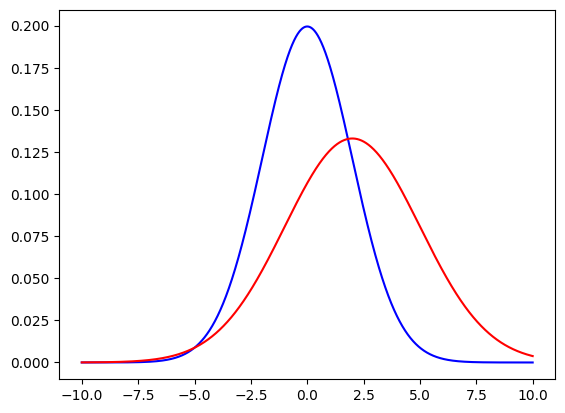

In [5]:
p = norm.pdf(x, 0, 2)
q = norm.pdf(x, 2, 3)
plt.plot(x, p, c= 'blue')
plt.plot(x, q, c= 'red')

In [6]:
kl(p, q)

np.float64(349.91348337868124)

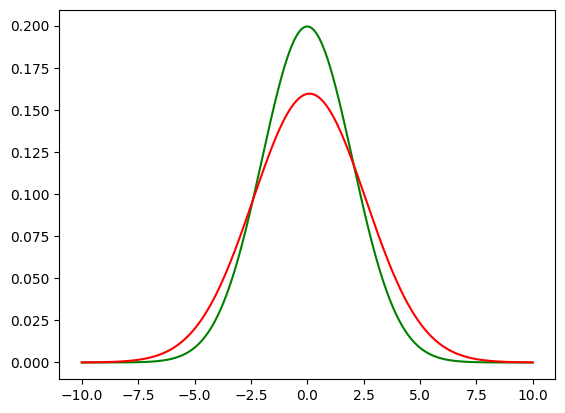

In [7]:
p = norm.pdf(x, 0, 2)
q = norm.pdf(x, 0.1, 2.5)
plt.plot(x, p, c='green')
plt.plot(x, q, c= 'red')

In [8]:
data = pd.read_csv('weight-height.csv')
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [9]:
data.groupby('Gender').mean

<bound method GroupBy.mean of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x000001F06ACD47D0>>

<Axes: >

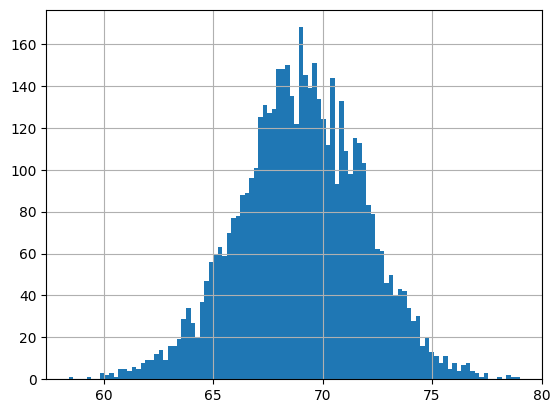

In [10]:
males = data[data['Gender'] == 'Male']['Height']
males.hist(bins=100)

In [11]:
males.describe()['mean']

np.float64(69.02634590621741)

In [12]:
males.describe()['std']

np.float64(2.863362228660647)

In [13]:
count, devision = np.histogram(males, bins=100)
print(count)
print(devision)

[  1   0   0   0   1   0   0   3   2   3   1   5   5   4   6   5   8   9
   9  12  14   9  16  16  19  29  34  27  20  37  47  56  60  63  59  70
  77  78  88  89  96 101 125 131 127 129 148 148 150 135 122 168 145 139
 151 134 124 112 144  93 133 109  98 115 113 103  83  79  62  61  46  50
  40  43  42  34  28  30  16  20  13  11   8  11   5   8   4   7   8   4
   3   1   3   0   0   1   0   2   1   1]
[58.40690493 58.61282331 58.81874168 59.02466005 59.23057843 59.4364968
 59.64241518 59.84833355 60.05425192 60.2601703  60.46608867 60.67200705
 60.87792542 61.0838438  61.28976217 61.49568054 61.70159892 61.90751729
 62.11343567 62.31935404 62.52527241 62.73119079 62.93710916 63.14302754
 63.34894591 63.55486429 63.76078266 63.96670103 64.17261941 64.37853778
 64.58445616 64.79037453 64.9962929  65.20221128 65.40812965 65.61404803
 65.8199664  66.02588478 66.23180315 66.43772152 66.6436399  66.84955827
 67.05547665 67.26139502 67.46731339 67.67323177 67.87915014 68.08506852
 68.290986

In [14]:
ideal = norm.rvs(size=len(males), loc = males.describe()['mean'], scale = males.describe()['std'])
print(ideal)

[73.16000258 67.74983555 70.40332805 ... 68.63982199 73.26425695
 68.34445063]


In [15]:
icount, idevision = np.histogram(ideal, bins=100)
print(icount)
print(devision)

[  1   1   0   0   0   3   3   1   1   3   4   4   6   4  10  15  17   6
  11  17  25  18  24  27  28  32  23  48  51  55  56  59  84  85  84 111
 103 121 124  88 118 129 124 112 141 145 143 146 142 140 149 129 134 142
 113 138 136 114 107 101  85  78  94  77  75  68  70  51  64  42  47  49
  28  30  30  13  21  19  15  18  16  12   5  10   3   6   5   3   5   1
   0   1   0   0   1   0   1   0   0   1]
[58.40690493 58.61282331 58.81874168 59.02466005 59.23057843 59.4364968
 59.64241518 59.84833355 60.05425192 60.2601703  60.46608867 60.67200705
 60.87792542 61.0838438  61.28976217 61.49568054 61.70159892 61.90751729
 62.11343567 62.31935404 62.52527241 62.73119079 62.93710916 63.14302754
 63.34894591 63.55486429 63.76078266 63.96670103 64.17261941 64.37853778
 64.58445616 64.79037453 64.9962929  65.20221128 65.40812965 65.61404803
 65.8199664  66.02588478 66.23180315 66.43772152 66.6436399  66.84955827
 67.05547665 67.26139502 67.46731339 67.67323177 67.87915014 68.08506852
 68.290986

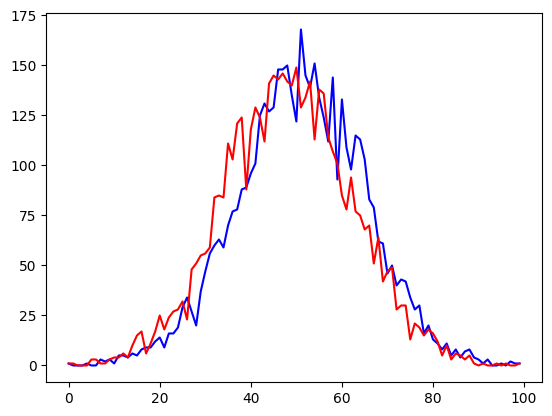

In [16]:
plt.plot(count, c='blue')
plt.plot(icount, c='red')